# About this Notebook

- **Data**: https://www.kaggle.com/datasets/waddahali/order-delivery-dataset
  
  
- **EDA**: https://www.kaggle.com/code/rudraprasadbhuyan/business-questions-order-delivery-eda
- **Geo EDA**: https://www.kaggle.com/code/rudraprasadbhuyan/order-delivery-geo-eda


- **Project 1:**
  - Predict the Delivery Time (Regression)
  - https://www.kaggle.com/code/rudraprasadbhuyan/project-1-predict-delivery-time
- **PROJECT 2**
  - Predict Order Cancellation (Classification)
  - https://www.kaggle.com/code/rudraprasadbhuyan/project-2-predict-order-cancellation

# Imports

In [30]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [4]:
from sklearn import set_config
set_config(display="diagram")

In [5]:
#import plotly.io as pio
#pio.renderers.default = "iframe_connected"

In [6]:
path = r"C:\Users\Rudra\Desktop\kaggle\order-delivery\talabat_enhanced_orders.csv"

In [7]:
df = pd.read_csv(path)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  object 
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  object 
 5   Quantity                   100000 non-null  int64  
 6   Total_Price                100000 non-null  float64
 7   Order_Time                 100000 non-null  object 
 8   Delivery_Time              100000 non-null  object 
 9   Delivery_Duration_Minutes  100000 non-null  int64  
 10  City                       100000 non-null  object 
 11  Payment_Method             100000 non-null  object 
 12  Order_Status               100000 non-null  object 
 13  Driver_Vehicle             100

In [9]:
df.columns

Index(['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name',
       'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time',
       'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status',
       'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
       'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km',
       'Traffic_Level', 'Driver_Availability'],
      dtype='object')

In [10]:
df = df.drop(columns=['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID',
                  'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
                    'Customer_Lon', 'Driver_Lat', 'Driver_Lon',
                    'Order_Time', 'Delivery_Time',
                 ])

In [11]:
df.head(2)

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,Fried Chicken,3,273.72,39,Alexandria,Wallet,Delivered,Motorbike,1.666106,High,Offline
1,Sandwich,3,365.82,33,Zagazig,Credit Card,Delivered,Motorbike,2.738698,Low,Online


In [12]:
df.columns

Index(['Item_Name', 'Quantity', 'Total_Price', 'Delivery_Duration_Minutes',
       'City', 'Payment_Method', 'Order_Status', 'Driver_Vehicle',
       'Delivery_Distance_km', 'Traffic_Level', 'Driver_Availability'],
      dtype='object')

# Splitting

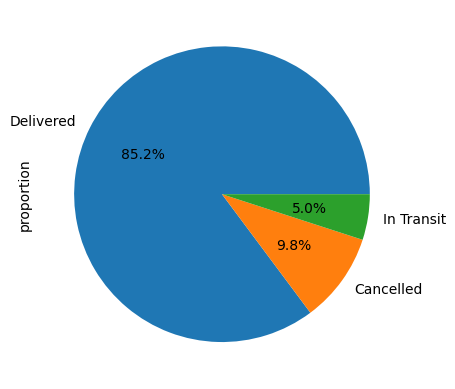

In [32]:
df["Order_Status"].value_counts(normalize=True).plot.pie(autopct="%2.1f%%")
plt.show()

In [13]:
X = df.drop(columns=["Order_Status"])
y = df["Order_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(80000, 10) (20000, 10)
(80000,) (20000,)


# Pipeline

In [16]:
df.columns

Index(['Item_Name', 'Quantity', 'Total_Price', 'Delivery_Duration_Minutes',
       'City', 'Payment_Method', 'Order_Status', 'Driver_Vehicle',
       'Delivery_Distance_km', 'Traffic_Level', 'Driver_Availability'],
      dtype='object')

In [19]:
df.select_dtypes(include=["object"]).drop(columns=["Order_Status"]).columns.to_list()

['Item_Name',
 'City',
 'Payment_Method',
 'Driver_Vehicle',
 'Traffic_Level',
 'Driver_Availability']

In [ ]:
df.select_dtypes(include=["float", "int"]).columns.to_list()

Index(['Quantity', 'Total_Price', 'Delivery_Duration_Minutes',
       'Delivery_Distance_km'],
      dtype='object')

In [21]:
target_col = "Order_Status"
categorical_cols = df.select_dtypes(include=["object"]).drop(columns=["Order_Status"]).columns.to_list()
numerical_cols = df.select_dtypes(include=["float", "int"]).columns.to_list()

In [22]:
preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(drop="first"),  categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

clf = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier())
])

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Item_Name', 'City',
                                                   'Payment_Method',
                                                   'Driver_Vehicle',
                                                   'Traffic_Level',
                                                   'Driver_Availability']),
                                                 ('num', StandardScaler(),
                                                  ['Quantity', 'Total_Price',
                                                   'Delivery_Duration_Minutes',
                                                   'Delivery_Distance_km'])])),
                ('model', RandomForestClassifier())])

# Prediction

In [23]:
y_pred = clf.predict(X_test)

In [26]:
print(f"Accuracy {accuracy_score(y_test, y_pred)}\n")
print(classification_report(y_test, y_pred))

Accuracy 0.8515

              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.14      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.33      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



- Recall of Cancelled or In Transit is 0.
- It means model learn only say Delivered.
- Very poor model.
- Don't see the accuracy.
- macro avg is 0.33
- It means model give equal importance to all the classes

In [ ]:
print(confusion_matrix(y_test, y_pred))

array([[    0,  1962,     1],
       [    5, 17029,     5],
       [    2,   995,     1]], dtype=int64)

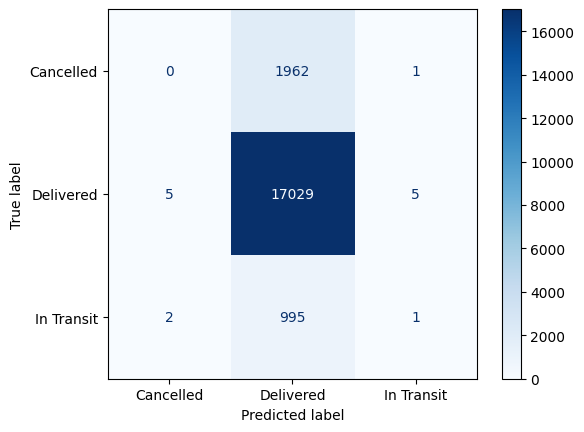

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap=plt.cm.Blues
)

plt.show()